# OS4 / OS5 multi-day metrics

This notebook compares behavioral metrics across days for OS4 and OS5 using **already-converted** HDF5 session files (`*.h5`).

It loads trial tables from `/events/Trials` and plots:
- Rolling accuracy (%) over trials across sessions/days
- Mean lick latency (`reaction_time_s`) by trial type (Go vs NoGo)
- d' (d-prime) across days

Adjust the parameters in the next cell (especially `H5_SEARCH_ROOT`) and run top-to-bottom.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "behavioral_analysis").exists():
            return candidate
    raise FileNotFoundError(f"Could not locate repository root starting from {start}")


repo_root = find_repo_root(Path.cwd())
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Repository root: {repo_root}")
print(f"Added to sys.path: {src_path}")


Repository root: /groups/spruston/home/moharb/DELTA_Behavior
Added to sys.path: /groups/spruston/home/moharb/DELTA_Behavior/src


In [2]:
# Parameters
ANIMALS = ["OS4", "OS5"]

# Directory to search recursively for HDF5 sessions.
# Recommended: point this at the folder where your converted H5 files live.
# Examples:
#   repo_root / "outputs" / "optostim-cli"
#   repo_root / "outputs" / "hdf5"
#   Path("/nearline/.../converted_h5")
H5_SEARCH_ROOT = repo_root / "outputs"

# If True, only keep files with "optostim" in the filename.
ONLY_OPTOSTIM_FILES = True

# If multiple H5 files represent the same session (e.g., debug re-runs), keep one.
DEDUPLICATE_SESSIONS = True

# When deduplicating, paths containing earlier hints are preferred.
PREFERRED_PATH_HINTS = ["optostim-cli", "hdf5"]

# Rolling window (trials) for the running accuracy plot.
ROLLING_WINDOW = 20

# Output folder for optional saved summaries/figures.
NOTEBOOK_OUTPUT_DIR = repo_root / "outputs" / "os4_os5_multi_day_metrics"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Searching for H5 sessions under: {H5_SEARCH_ROOT}")
print(f"Writing outputs to: {NOTEBOOK_OUTPUT_DIR}")


Searching for H5 sessions under: /groups/spruston/home/moharb/DELTA_Behavior/outputs
Writing outputs to: /groups/spruston/home/moharb/DELTA_Behavior/outputs/os4_os5_multi_day_metrics


In [3]:
from __future__ import annotations

import re
from datetime import date, datetime

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FixedLocator
from scipy.stats import norm


sns.set_theme(style="whitegrid")

_DATE_PATTERN = re.compile(r"(20\d{2})[-_](\d{2})[-_](\d{2})")
_SESSION_PATTERN = re.compile(r"session[_\\s-]*(\d+)", re.IGNORECASE)


def infer_session_metadata(path: Path) -> tuple[date, int | None]:
    """Infer session date and session number from the filename/path."""
    stem = path.stem

    date_match = _DATE_PATTERN.search(stem) or _DATE_PATTERN.search(path.as_posix())
    if date_match:
        year, month, day = map(int, date_match.groups())
        session_date = date(year, month, day)
    else:
        session_date = datetime.fromtimestamp(path.stat().st_mtime).date()

    session_match = _SESSION_PATTERN.search(stem)
    session_number = int(session_match.group(1)) if session_match else None

    return session_date, session_number


def build_session_label(session_date: date, session_number: int | None, path: Path) -> str:
    if session_number is not None:
        return f"{session_date.isoformat()} - session {session_number:d}"
    return f"{session_date.isoformat()} - {path.stem}"


def _path_preference_rank(path: Path, preferred_hints: list[str]) -> tuple[int, int, str]:
    lower = path.as_posix().lower()
    for idx, hint in enumerate(preferred_hints):
        if hint.lower() in lower:
            return (idx, len(lower), lower)
    return (len(preferred_hints), len(lower), lower)


def discover_h5_sessions(
    animal_id: str,
    search_root: Path,
    *,
    only_optostim: bool,
    deduplicate: bool,
    preferred_hints: list[str],
) -> list[Path]:
    root = Path(search_root)
    if not root.exists():
        raise FileNotFoundError(f"H5_SEARCH_ROOT does not exist: {root}")

    token = animal_id.lower()
    candidates = [p for p in root.rglob("*.h5") if token in p.name.lower()]
    if only_optostim:
        candidates = [p for p in candidates if "optostim" in p.name.lower()]

    # Sort for stable grouping.
    candidates = sorted(
        candidates,
        key=lambda p: (*infer_session_metadata(p), _path_preference_rank(p, preferred_hints), p.name.lower()),
    )

    if deduplicate:
        best_by_session: dict[tuple[date, int | None, str], Path] = {}
        for p in candidates:
            session_date, session_number = infer_session_metadata(p)
            session_key = (session_date, session_number, p.stem.lower())
            existing = best_by_session.get(session_key)
            if existing is None:
                best_by_session[session_key] = p
                continue

            if _path_preference_rank(p, preferred_hints) < _path_preference_rank(existing, preferred_hints):
                best_by_session[session_key] = p

        candidates = sorted(
            best_by_session.values(),
            key=lambda p: (*infer_session_metadata(p), _path_preference_rank(p, preferred_hints), p.name.lower()),
        )

    return candidates


def load_trials_from_h5(h5_path: Path) -> pd.DataFrame:
    """Load `/events/Trials` and normalize a few column names."""
    with pd.HDFStore(str(h5_path), mode="r") as store:
        if "/events/Trials" not in store:
            raise KeyError(f"Missing /events/Trials in {h5_path}")
        trials = store["/events/Trials"].copy()

    if trials.empty:
        return trials

    # Standardize outcome/correct if missing.
    if "outcome" in trials.columns and "correct" not in trials.columns:
        trials["correct"] = trials["outcome"].isin(["Hit", "CR"])

    # Standardize reaction_time_s if missing.
    if "reaction_time_s" not in trials.columns:
        if {"cue_onset_ms", "cue_outcome_ms"}.issubset(trials.columns):
            trials["reaction_time_s"] = (trials["cue_outcome_ms"] - trials["cue_onset_ms"]) / 1000.0
        else:
            trials["reaction_time_s"] = np.nan

    # Standardize is_rewarding if missing.
    if "is_rewarding" not in trials.columns:
        if "cue_type" in trials.columns:
            trials["is_rewarding"] = trials["cue_type"].astype(str).str.lower().str.contains("reward")
        elif "trial_type" in trials.columns:
            trials["is_rewarding"] = trials["trial_type"].astype(str).str.strip().str.lower().eq("go")
        else:
            trials["is_rewarding"] = False

    # Canonical trial type label.
    trials["trial_class"] = np.where(trials["is_rewarding"].astype(bool), "Go", "NoGo")

    sort_columns = [
        col
        for col in ("trial_id", "trial_number", "cue_onset_ms", "start_time_ms")
        if col in trials.columns
    ]
    if sort_columns:
        trials = trials.sort_values(sort_columns).reset_index(drop=True)
    else:
        trials = trials.reset_index(drop=True)

    trials["trial_in_session"] = np.arange(1, len(trials) + 1)
    return trials


def dprime_from_trials(trials: pd.DataFrame) -> float:
    """Compute d' with log-linear correction to avoid infinities at 0/1 rates."""
    if trials.empty:
        return np.nan

    if "outcome" not in trials.columns or "is_rewarding" not in trials.columns:
        return np.nan

    is_rewarding = trials["is_rewarding"].astype(bool)
    n_rewarding = int(is_rewarding.sum())
    n_non_rewarding = int((~is_rewarding).sum())
    if n_rewarding == 0 or n_non_rewarding == 0:
        return np.nan

    hits = int((trials["outcome"] == "Hit").sum())
    fas = int((trials["outcome"] == "FA").sum())

    hit_rate = (hits + 0.5) / (n_rewarding + 1.0)
    fa_rate = (fas + 0.5) / (n_non_rewarding + 1.0)

    return float(norm.ppf(hit_rate) - norm.ppf(fa_rate))


def summarize_block(trials: pd.DataFrame) -> dict:
    """Summarize a trials block (session or day)."""
    if trials.empty:
        return {
            "n_trials": 0,
            "accuracy_pct": np.nan,
            "hit_rate": np.nan,
            "fa_rate": np.nan,
            "d_prime": np.nan,
            "go_mean_latency_s": np.nan,
            "nogo_mean_latency_s": np.nan,
        }

    correct = trials["correct"].astype(float) if "correct" in trials.columns else pd.Series(np.nan, index=trials.index)
    accuracy_pct = float(correct.mean() * 100.0) if correct.notna().any() else np.nan

    is_rewarding = trials["is_rewarding"].astype(bool)
    n_rewarding = int(is_rewarding.sum())
    n_non_rewarding = int((~is_rewarding).sum())

    hits = int((trials.get("outcome") == "Hit").sum()) if "outcome" in trials.columns else 0
    fas = int((trials.get("outcome") == "FA").sum()) if "outcome" in trials.columns else 0

    hit_rate = hits / n_rewarding if n_rewarding else np.nan
    fa_rate = fas / n_non_rewarding if n_non_rewarding else np.nan

    go_latency = trials.loc[trials["trial_class"] == "Go", "reaction_time_s"].mean()
    nogo_latency = trials.loc[trials["trial_class"] == "NoGo", "reaction_time_s"].mean()

    return {
        "n_trials": int(len(trials)),
        "accuracy_pct": accuracy_pct,
        "hit_rate": float(hit_rate) if hit_rate == hit_rate else np.nan,
        "fa_rate": float(fa_rate) if fa_rate == fa_rate else np.nan,
        "d_prime": dprime_from_trials(trials),
        "go_mean_latency_s": float(go_latency) if go_latency == go_latency else np.nan,
        "nogo_mean_latency_s": float(nogo_latency) if nogo_latency == nogo_latency else np.nan,
    }


In [4]:
# Discover sessions and load trials

all_trials_by_animal: dict[str, pd.DataFrame] = {}
session_paths_table_rows: list[dict] = []

for animal_id in ANIMALS:
    h5_paths = discover_h5_sessions(
        animal_id,
        H5_SEARCH_ROOT,
        only_optostim=ONLY_OPTOSTIM_FILES,
        deduplicate=DEDUPLICATE_SESSIONS,
        preferred_hints=PREFERRED_PATH_HINTS,
    )
    if not h5_paths:
        raise FileNotFoundError(f"No HDF5 sessions found for {animal_id} under {H5_SEARCH_ROOT}")

    for p in h5_paths:
        session_date, session_number = infer_session_metadata(p)
        session_paths_table_rows.append(
            {
                "animal_id": animal_id,
                "h5_path": p.as_posix(),
                "session_date": session_date,
                "session_number": session_number,
            }
        )

    session_frames: list[pd.DataFrame] = []
    for p in h5_paths:
        session_date, session_number = infer_session_metadata(p)
        session_label = build_session_label(session_date, session_number, p)

        trials = load_trials_from_h5(p)
        if trials.empty:
            continue

        trials["animal_id"] = animal_id
        trials["session_date"] = session_date
        trials["session_number"] = session_number
        trials["session_label"] = session_label
        trials["source_hdf5"] = p.as_posix()
        session_frames.append(trials)

    if not session_frames:
        raise RuntimeError(f"No non-empty Trials tables loaded for {animal_id}")

    trials_all = pd.concat(session_frames, ignore_index=True)
    trials_all = trials_all.sort_values(
        ["session_date", "session_number", "trial_in_session"],
        kind="mergesort",
        na_position="last",
    ).reset_index(drop=True)

    trials_all["trial_index_global"] = np.arange(1, len(trials_all) + 1)
    trials_all["rolling_accuracy_pct"] = (
        trials_all["correct"].astype(float).rolling(ROLLING_WINDOW, min_periods=1).mean() * 100.0
    )

    all_trials_by_animal[animal_id] = trials_all

session_paths_table = pd.DataFrame(session_paths_table_rows)
session_paths_table.sort_values(["animal_id", "session_date", "session_number", "h5_path"], inplace=True)
session_paths_table.reset_index(drop=True, inplace=True)
session_paths_table


,animal_id,h5_path,session_date,session_number
0,OS4,/groups/spruston/home/moharb/DELTA_Behavior/ou...,2025-12-15,None
1,OS4,/groups/spruston/home/moharb/DELTA_Behavior/ou...,2025-12-16,None
2,OS4,/groups/spruston/home/moharb/DELTA_Behavior/ou...,2025-12-17,None
3,OS4,/groups/spruston/home/moharb/DELTA_Behavior/ou...,2025-12-18,None
4,OS4,/groups/spruston/home/moharb/DELTA_Behavior/ou...,2025-12-19,None
5,OS5,/groups/spruston/home/moharb/DELTA_Behavior/ou...,2025-12-15,None
6,OS5,/groups/spruston/home/moharb/DELTA_Behavior/ou...,2025-12-16,None
7,OS5,/groups/spruston/home/moharb/DELTA_Behavior/ou...,2025-12-17,None
8,OS5,/groups/spruston/home/moharb/DELTA_Behavior/ou...,2025-12-18,None
9,OS5,/groups/spruston/home/moharb/DELTA_Behavior/ou...,2025-12-19,None


In [5]:
# Session-level and day-level summaries

all_trials = pd.concat(all_trials_by_animal.values(), ignore_index=True)

session_summary_rows: list[dict] = []
for (animal_id, session_date, session_number, session_label), block in all_trials.groupby(
    ["animal_id", "session_date", "session_number", "session_label"],
    dropna=False,
    sort=True,
):
    row = {
        "animal_id": animal_id,
        "session_date": session_date,
        "session_number": session_number,
        "session_label": session_label,
    }
    row.update(summarize_block(block))
    session_summary_rows.append(row)

session_summary = pd.DataFrame(session_summary_rows).sort_values(
    ["animal_id", "session_date", "session_number"],
    na_position="last",
)

day_summary_rows: list[dict] = []
for (animal_id, session_date), block in all_trials.groupby(["animal_id", "session_date"], sort=True):
    row = {"animal_id": animal_id, "session_date": session_date}
    row.update(summarize_block(block))
    day_summary_rows.append(row)

day_summary = pd.DataFrame(day_summary_rows).sort_values(["animal_id", "session_date"]).reset_index(drop=True)

display(session_summary)
day_summary


,animal_id,session_date,session_number,session_label,n_trials,accuracy_pct,hit_rate,fa_rate,d_prime,go_mean_latency_s,nogo_mean_latency_s
0,OS4,2025-12-15,NaN,2025-12-15 - Log OS4 2025-12-15 session 1_opto...,293,9.897611,NaN,0.901024,NaN,NaN,0.938055
1,OS4,2025-12-16,NaN,2025-12-16 - Log OS4 2025-12-16 session 2_opto...,233,57.081545,0.859649,0.705882,0.528400,1.075117,1.709028
2,OS4,2025-12-17,NaN,2025-12-17 - Log OS4 2025-12-17 session 1_opto...,245,62.448980,0.983871,0.743802,1.404834,0.389595,1.422211
3,OS4,2025-12-18,NaN,2025-12-18 - Log OS4 2025-12-18 session 1_opto...,311,66.881029,0.992908,0.600000,2.053878,0.298784,1.153079
4,OS4,2025-12-19,NaN,2025-12-19 - Log OS4 2025-12-19 session 1_opto...,277,91.696751,0.992248,0.148649,3.304284,0.295194,1.735570
5,OS5,2025-12-15,NaN,2025-12-15 - Log OS5 2025-12-15 session 1_opto...,277,11.191336,NaN,0.888087,NaN,NaN,0.962669
6,OS5,2025-12-16,NaN,2025-12-16 - Log OS5 2025-12-16 session 1_opto...,235,65.957447,0.890909,0.544000,1.103115,0.993972,2.203599
7,OS5,2025-12-17,NaN,2025-12-17 - Log OS5 2025-12-17 session 1_opto...,298,75.503356,0.986014,0.458065,2.216217,0.234898,1.502600
8,OS5,2025-12-18,NaN,2025-12-18 - Log OS5 2025-12-18 session 1_opto...,307,87.947883,0.866667,0.108280,2.322061,0.429313,3.076253
9,OS5,2025-12-19,NaN,2025-12-19 - Log OS5 2025-12-19 session 1_opto...,261,99.616858,0.992248,0.000000,4.945106,0.604935,8.231850


,animal_id,session_date,n_trials,accuracy_pct,hit_rate,fa_rate,d_prime,go_mean_latency_s,nogo_mean_latency_s
0,OS4,2025-12-15,293,9.897611,NaN,0.901024,NaN,NaN,0.938055
1,OS4,2025-12-16,233,57.081545,0.859649,0.705882,0.528400,1.075117,1.709028
2,OS4,2025-12-17,245,62.448980,0.983871,0.743802,1.404834,0.389595,1.422211
3,OS4,2025-12-18,311,66.881029,0.992908,0.600000,2.053878,0.298784,1.153079
4,OS4,2025-12-19,277,91.696751,0.992248,0.148649,3.304284,0.295194,1.735570
5,OS5,2025-12-15,277,11.191336,NaN,0.888087,NaN,NaN,0.962669
6,OS5,2025-12-16,235,65.957447,0.890909,0.544000,1.103115,0.993972,2.203599
7,OS5,2025-12-17,298,75.503356,0.986014,0.458065,2.216217,0.234898,1.502600
8,OS5,2025-12-18,307,87.947883,0.866667,0.108280,2.322061,0.429313,3.076253
9,OS5,2025-12-19,261,99.616858,0.992248,0.000000,4.945106,0.604935,8.231850


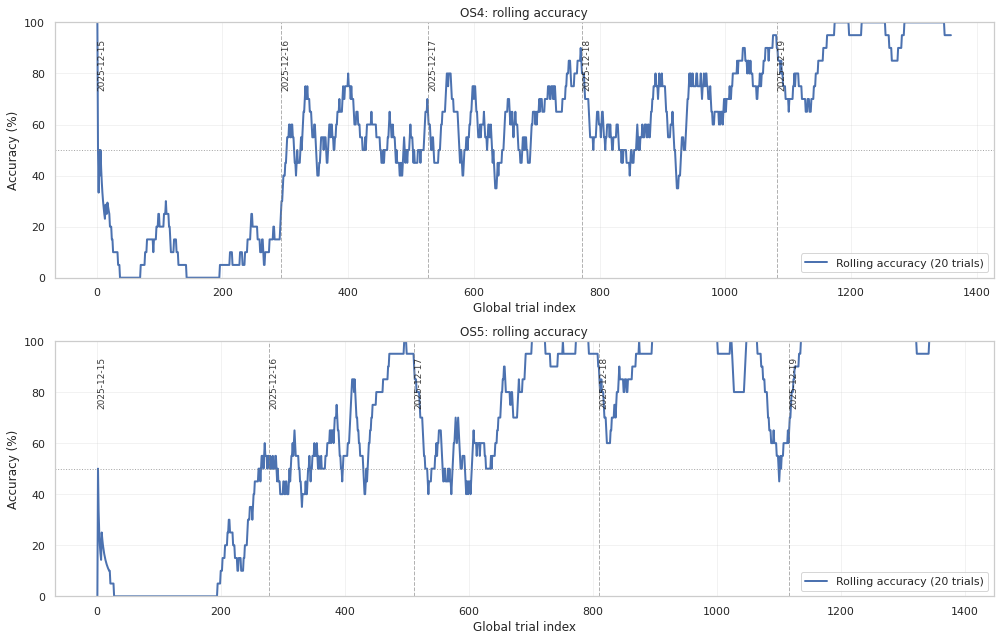

In [6]:
# Plot 1: rolling accuracy over global trial index (per animal)

nrows = len(ANIMALS)
fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(14, 4.5 * nrows), sharex=False, sharey=True)
if nrows == 1:
    axes = [axes]

for ax, animal_id in zip(axes, ANIMALS):
    trials = all_trials_by_animal[animal_id]
    ax.plot(
        trials["trial_index_global"],
        trials["rolling_accuracy_pct"],
        linewidth=2,
        label=f"Rolling accuracy ({ROLLING_WINDOW} trials)",
    )
    ax.axhline(50, color="gray", linestyle=":", linewidth=1, alpha=0.7)
    ax.set_title(f"{animal_id}: rolling accuracy")
    ax.set_xlabel("Global trial index")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.25)

    # Day transition markers
    day_first_indices = (
        trials.groupby("session_date")["trial_index_global"].min().sort_index().tolist()
    )
    for idx in day_first_indices[1:]:
        ax.axvline(idx - 0.5, linestyle="--", color="gray", linewidth=1, alpha=0.6)

    ymin, ymax = ax.get_ylim()
    label_y = ymax - (ymax - ymin) * 0.06
    for d, idx in trials.groupby("session_date")["trial_index_global"].min().sort_index().items():
        ax.text(idx, label_y, str(d), fontsize=9, rotation=90, va="top", ha="left", alpha=0.9)

    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


/groups/spruston/home/moharb/mambaforge/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/groups/spruston/home/moharb/.tmp_vscode/ipykernel_3964356/3502651901.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


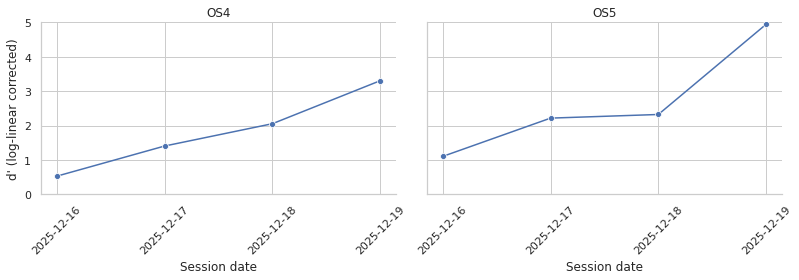

In [7]:
# Plot 2: d' across days (per animal)

g = sns.relplot(
    data=day_summary,
    x="session_date",
    y="d_prime",
    col="animal_id",
    kind="line",
    marker="o",
    facet_kws={"sharey": True, "sharex": True},
    height=4,
    aspect=1.4,
)
g.set_titles("{col_name}")

for ax, (animal_id, subdf) in zip(g.axes.flat, day_summary.groupby("animal_id", sort=True)):
    ax.axhline(0, color="gray", linestyle=":", linewidth=1)
    unique_dates = sorted(subdf["session_date"].unique())
    date_nums = mdates.date2num(unique_dates)
    ax.xaxis.set_major_locator(FixedLocator(date_nums))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Session date")
    ax.set_ylabel("d' (log-linear corrected)")
plt.ylim([0, 5])
plt.tight_layout()
plt.show()


/groups/spruston/home/moharb/mambaforge/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/groups/spruston/home/moharb/.tmp_vscode/ipykernel_3964356/371541539.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


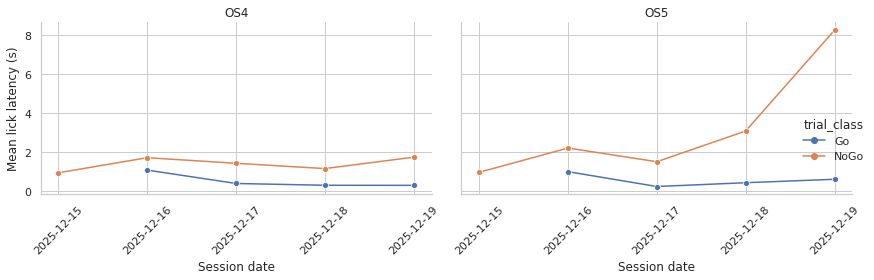

In [8]:
# Plot 3: mean lick latency by trial type (Go vs NoGo) across days

latency_long = day_summary.melt(
    id_vars=["animal_id", "session_date"],
    value_vars=["go_mean_latency_s", "nogo_mean_latency_s"],
    var_name="trial_class",
    value_name="mean_latency_s",
)
latency_long["trial_class"] = latency_long["trial_class"].map(
    {"go_mean_latency_s": "Go", "nogo_mean_latency_s": "NoGo"}
)

g = sns.relplot(
    data=latency_long,
    x="session_date",
    y="mean_latency_s",
    hue="trial_class",
    col="animal_id",
    kind="line",
    marker="o",
    facet_kws={"sharey": True, "sharex": True},
    height=4,
    aspect=1.4,
)
g.set_titles("{col_name}")
for ax in g.axes.flat:
    unique_dates = sorted(subdf["session_date"].unique())
    date_nums = mdates.date2num(unique_dates)
    ax.xaxis.set_major_locator(FixedLocator(date_nums))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Session date")
    ax.set_ylabel("Mean lick latency (s)")

plt.tight_layout()
plt.show()


In [9]:
# Optional: save summaries to CSV

session_csv = NOTEBOOK_OUTPUT_DIR / "os4_os5_session_summary.csv"
day_csv = NOTEBOOK_OUTPUT_DIR / "os4_os5_day_summary.csv"

session_summary.to_csv(session_csv, index=False)
day_summary.to_csv(day_csv, index=False)

print(f"Wrote: {session_csv}")
print(f"Wrote: {day_csv}")


Wrote: /groups/spruston/home/moharb/DELTA_Behavior/outputs/os4_os5_multi_day_metrics/os4_os5_session_summary.csv
Wrote: /groups/spruston/home/moharb/DELTA_Behavior/outputs/os4_os5_multi_day_metrics/os4_os5_day_summary.csv
